# **Exploratory Data Analysis**

**What is Exploratory Data Analysis ?**

Exploratory Data Analysis or (EDA) is understanding the data sets by summarizing their main characteristics often plotting them visually. This step is very important especially when we arrive at modeling the data in order to apply Machine learning. Plotting in EDA consists of Histograms, Box plot, Scatter plot and many more. It often takes much time to explore the data. Through the process of EDA, we can ask to define the problem statement or definition on our data set which is very important.

**How to perform Exploratory Data Analysis ?**

This is one such question that everyone is keen on knowing the answer. Well, the answer is it depends on the data set that you are working. There is no one method or common methods in order to perform EDA, whereas in this tutorial you can understand some common methods and plots that would be used in the EDA process.

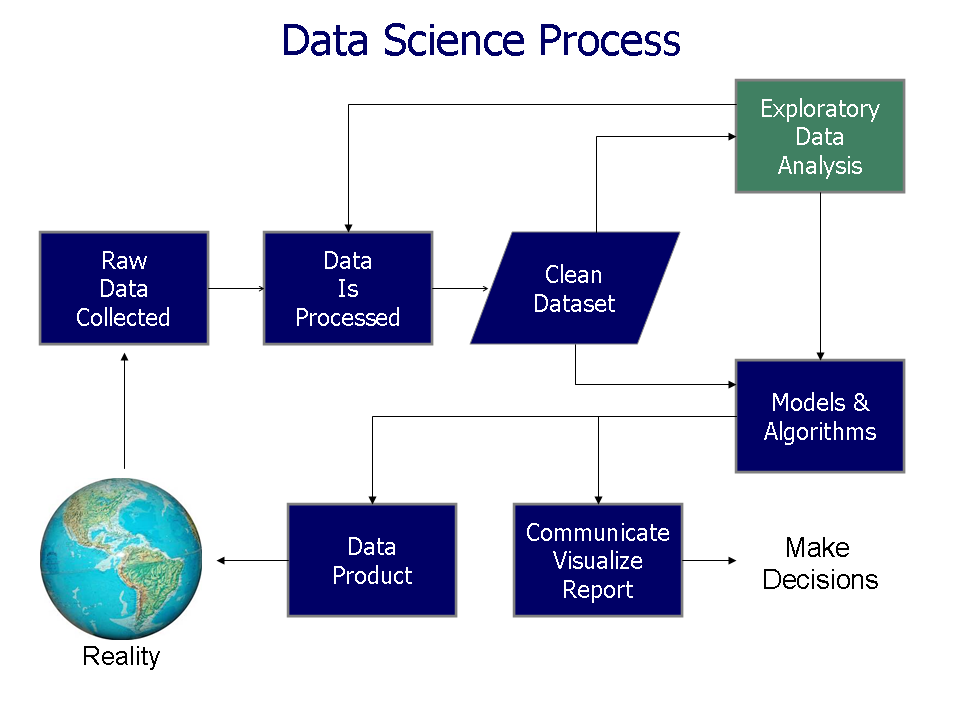

Sai is a selection officer(ML Model): He needs to predict whether a candidate suitable for police job or not
Features:  Height(>160cms), marks(150), age(<35), long jump(7 meters), running(1600 mts by 5 mins), qualification(Any degree), selection/Rejection


Height(>160cms), marks(150), age(<35), long jump(7 meters), running(1600 mts by 5 mins), qualification(Any degree)




**Types of EDA Techniques**

Before diving into the dataset, let’s first understand the different types of Exploratory Data Analysis (EDA) techniques. Here are five key types of EDA techniques:

**Univariate Analysis:** Univariate analysis examines individual variables to understand their distributions and summary statistics. This includes calculating measures such as mean, median, mode, and standard deviation, and visualizing the data using histograms, bar charts, box plots, and violin plots.

**Bivariate Analysis:** Bivariate analysis explores the relationship between two variables. It uncovers patterns through techniques like scatter plots, pair plots, and heatmaps. This helps to identify potential associations or dependencies between variables.

**Multivariate Analysis:** Multivariate analysis involves examining more than two variables simultaneously to understand their relationships and combined effects. Techniques such as contour plots, and principal component analysis (PCA) are commonly used in multivariate EDA.

**Visualization Techniques:** EDA relies heavily on visualization methods to depict data distributions, trends, and associations. Various charts and graphs, such as bar charts, line charts, scatter plots, and heatmaps, are used to make data easier to understand and interpret.

**Outlier Detection:** EDA involves identifying outliers within the data—anomalies that deviate significantly from the rest of the data. Tools such as box plots, z-score analysis, and scatter plots help in detecting and analyzing outliers.

**Statistical Tests:** EDA often includes performing statistical tests to validate hypotheses or discern significant differences between groups. Tests such as t-tests, chi-square tests, and ANOVA add depth to the analysis process by providing a statistical basis for the observed patterns.

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline
import warnings
warnings.filterwarnings('ignore') 

In [2]:
dataset = pd.read_csv('StudentsPerformance.csv', encoding="windows-1252")
dataset.sample(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
45,male,group B,associate's degree,standard,none,65,54,57
362,female,group C,some college,standard,none,52,58,58
707,male,group C,some college,standard,none,66,59,52
553,male,group D,some college,free/reduced,none,77,62,64
32,female,group E,master's degree,free/reduced,none,56,72,65
408,female,group D,high school,free/reduced,completed,52,57,56
977,male,group C,associate's degree,standard,none,62,65,58
27,female,group C,bachelor's degree,standard,none,67,69,75
569,male,group D,bachelor's degree,free/reduced,none,68,68,67
776,female,group B,high school,standard,none,66,72,70


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
dataset.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
dataset.shape

(1000, 8)

In [5]:
dataset.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Univariate Variable Analysis**

* Categorical Variables: 'gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'

* Numerical Variables: 'math score', 'reading score', 'writing score'.

In [7]:
def bar_plot(variable):
    """
        input: variable ex: "Sex"
        output: bar plot & value count
    """
    # get feature
    var = dataset[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()
    
    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}:\n{}".format(variable,varValue))

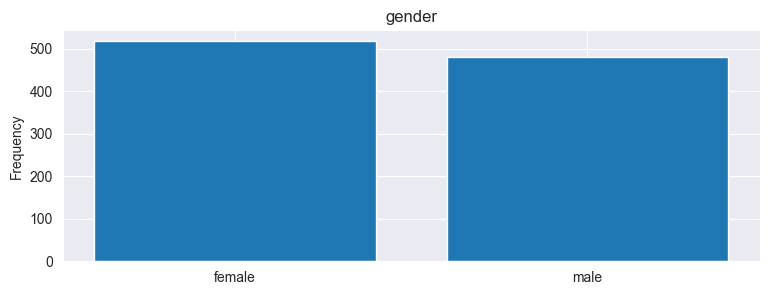

gender:
gender
female    518
male      482
Name: count, dtype: int64


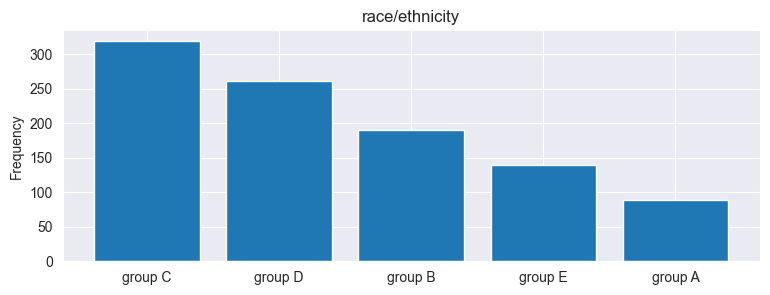

race/ethnicity:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


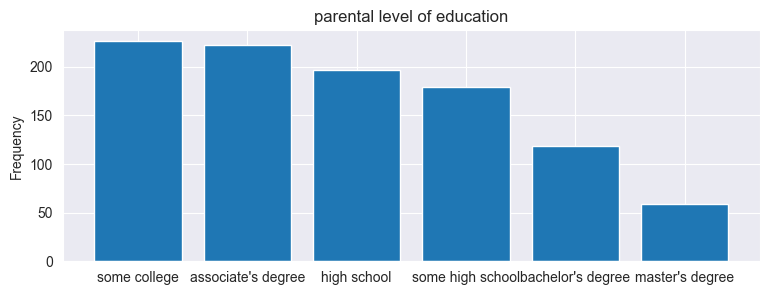

parental level of education:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


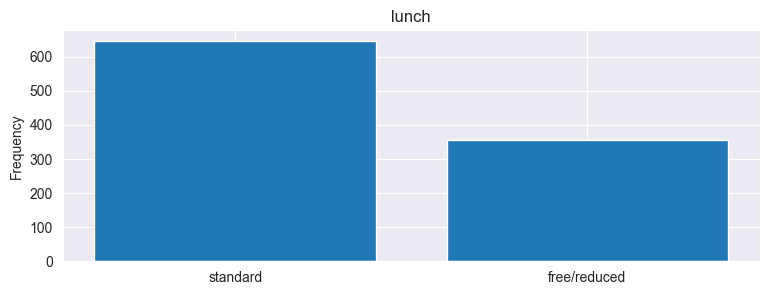

lunch:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64


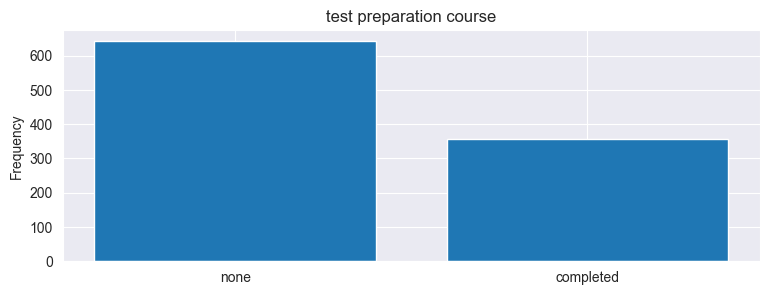

test preparation course:
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [8]:
sns.set_style('darkgrid')
categorical_variables = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for c in categorical_variables:
    bar_plot(c)

**Numerical Variables**

In [33]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(dataset[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

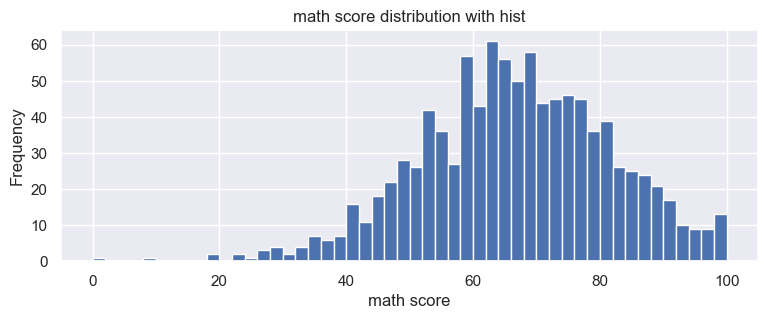

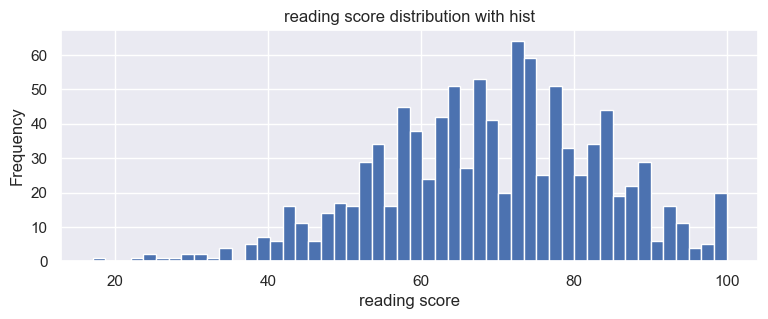

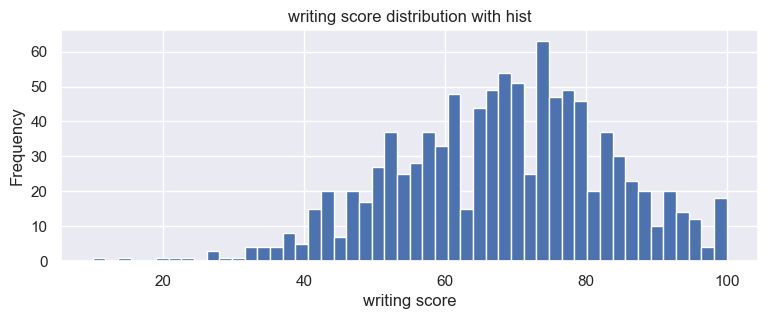

In [34]:
numerical_variables = ['math score', 'reading score', 'writing score']
for n in numerical_variables:
    plot_hist(n)

**Basic Data Analysis**

**gender**

In [35]:
dataset[["gender","math score"]].groupby(["gender"], as_index = False).mean().sort_values(by="math score",ascending = False)

,gender,math score
1,male,68.728216
0,female,63.633205


In [36]:
dataset[["gender","reading score"]].groupby(["gender"], as_index = False).mean().sort_values(by="reading score",ascending = False)

,gender,reading score
0,female,72.608108
1,male,65.473029


In [37]:
dataset[["gender","writing score"]].groupby(["gender"], as_index = False).mean().sort_values(by="writing score",ascending = False)

,gender,writing score
0,female,72.467181
1,male,63.311203


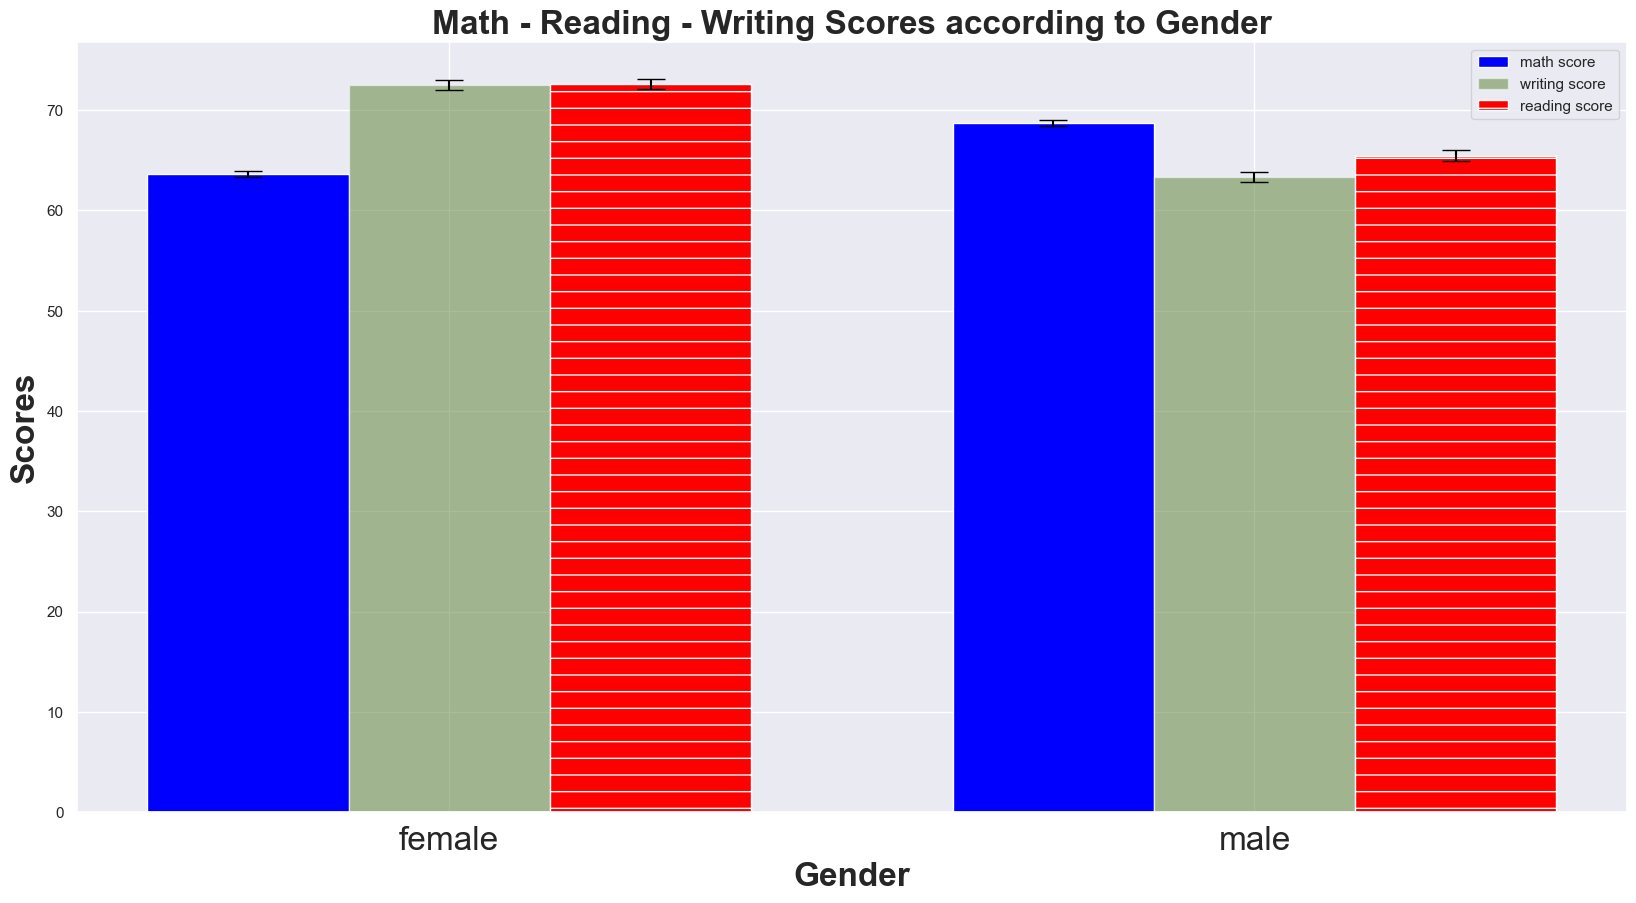

In [38]:
race_math = dataset[["gender","math score"]].groupby(["gender"], as_index = False).mean()
race_writing = dataset[["gender","writing score"]].groupby(["gender"], as_index = False).mean()
race_reading = dataset[["gender","reading score"]].groupby(["gender"], as_index = False).mean()

plt.figure(figsize=(20,10))
sns.set_theme(style="darkgrid")
plt.title('Math - Reading - Writing Scores according to Gender', fontweight='bold', size = 24)

barWidth = 0.25
 
bars1 = race_math['math score']
bars2 = race_writing['writing score']
bars3 = race_reading['reading score']

 
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]
 
plt.bar(r1, bars1, color='blue', width=barWidth, edgecolor='white', label='math score', yerr=0.3,ecolor="black",capsize=10)
plt.bar(r2, bars2, color='#557f2d', width=barWidth, edgecolor='white', label='writing score', yerr=0.5,ecolor="black",capsize=10, alpha = .50)
plt.bar(r3, bars3, color='red', width=barWidth, edgecolor='white', label='reading score', yerr=0.5,ecolor="black",capsize=10, hatch = '-')

modelNames = race_math['gender']
    
plt.xlabel('Gender', fontweight='bold', size = 24)
plt.ylabel('Scores', fontweight='bold', size = 24)
plt.xticks([r + barWidth for r in range(len(bars1))], modelNames, rotation = 0, size = 24)
plt.legend()
plt.show()

**Insights**

!!! Except for the math score, females have higher averages. !!!

**race/etinity**

In [39]:
dataset[["race/ethnicity","math score"]].groupby(["race/ethnicity"], as_index = False).mean().sort_values(by="math score",ascending = False)

,race/ethnicity,math score
4,group E,73.821429
3,group D,67.362595
2,group C,64.463950
1,group B,63.452632
0,group A,61.629213


In [40]:
dataset[["race/ethnicity","reading score"]].groupby(["race/ethnicity"], as_index = False).mean().sort_values(by="reading score",ascending = False)

,race/ethnicity,reading score
4,group E,73.028571
3,group D,70.030534
2,group C,69.103448
1,group B,67.352632
0,group A,64.674157


In [41]:
dataset[["race/ethnicity","writing score"]].groupby(["race/ethnicity"], as_index = False).mean().sort_values(by="writing score",ascending = False)

,race/ethnicity,writing score
4,group E,71.407143
3,group D,70.145038
2,group C,67.827586
1,group B,65.600000
0,group A,62.674157


In [42]:
dataset[["race/ethnicity","writing score"]].groupby(["race/ethnicity"], as_index = False).mean().sort_values(by="writing score",ascending = False)

,race/ethnicity,writing score
4,group E,71.407143
3,group D,70.145038
2,group C,67.827586
1,group B,65.600000
0,group A,62.674157


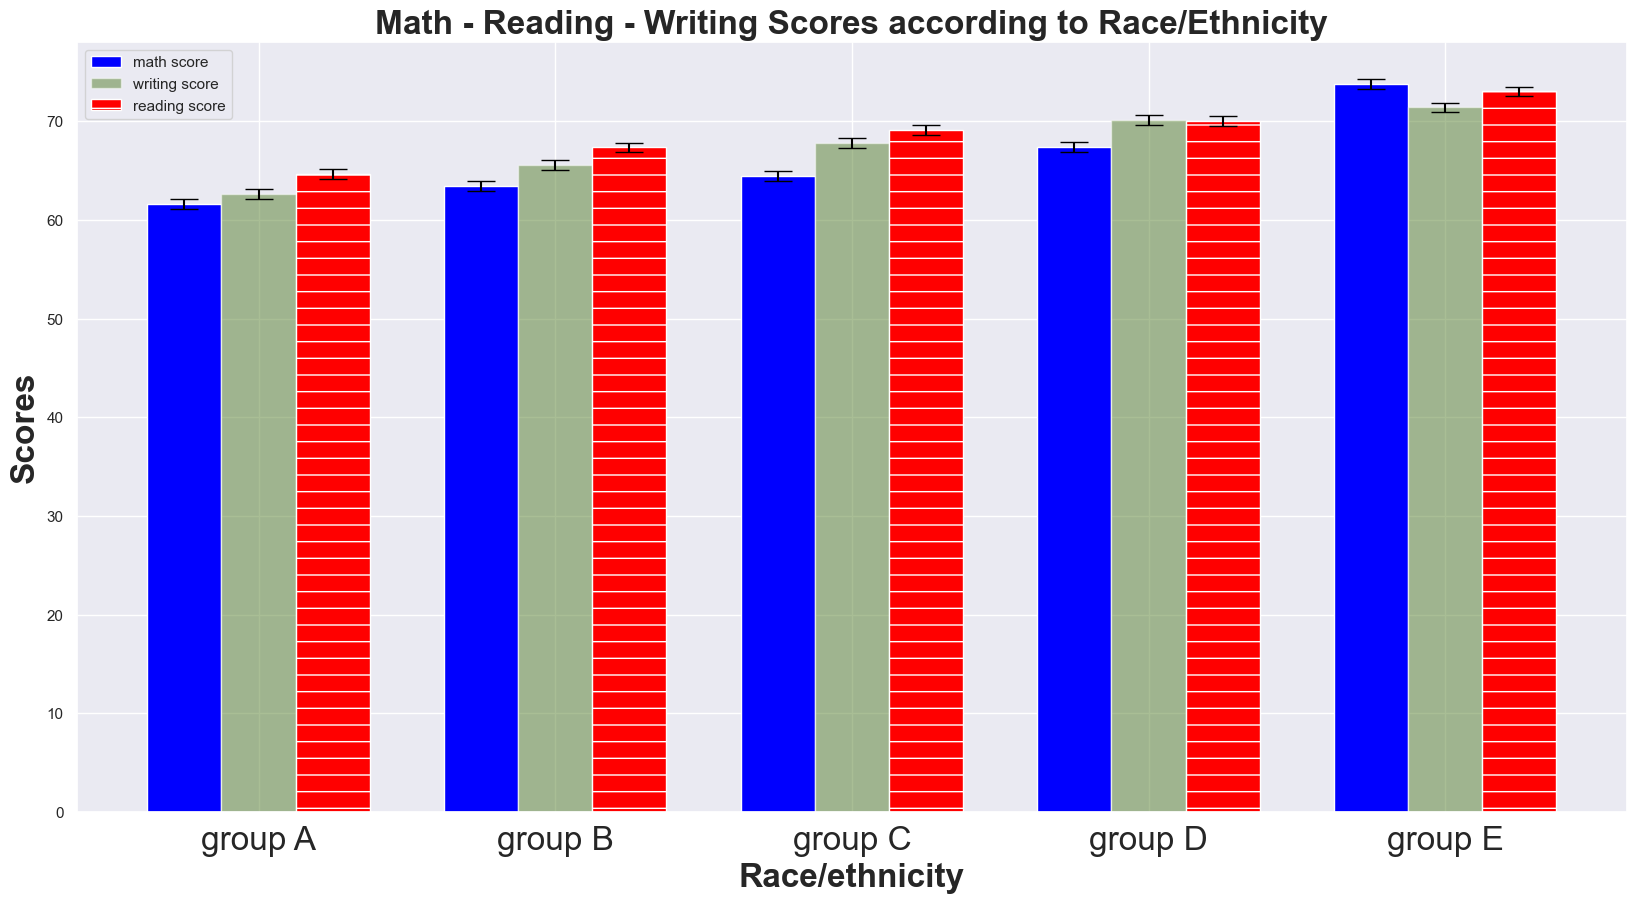

In [43]:
race_math = dataset[["race/ethnicity","math score"]].groupby(["race/ethnicity"], as_index = False).mean()
race_writing = dataset[["race/ethnicity","writing score"]].groupby(["race/ethnicity"], as_index = False).mean()
race_reading = dataset[["race/ethnicity","reading score"]].groupby(["race/ethnicity"], as_index = False).mean()

plt.figure(figsize=(20,10))
sns.set_theme(style="darkgrid")
plt.title('Math - Reading - Writing Scores according to Race/Ethnicity', fontweight='bold', size = 24)

barWidth = 0.25
 
bars1 = race_math['math score']
bars2 = race_writing['writing score']
bars3 = race_reading['reading score']
 
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
 
plt.bar(r1, bars1, color='blue', width=barWidth, edgecolor='white', label='math score', yerr=0.5,ecolor="black",capsize=10)
plt.bar(r2, bars2, color='#557f2d', width=barWidth, edgecolor='white', label='writing score', yerr=0.5,ecolor="black",capsize=10, alpha = .50)
plt.bar(r3, bars3, color='red', width=barWidth, edgecolor='white', label='reading score', yerr=0.5,ecolor="black",capsize=10, hatch = '-')
 
modelNames = race_math['race/ethnicity']
    
plt.xlabel('Race/ethnicity', fontweight='bold', size = 24)
plt.ylabel('Scores', fontweight='bold', size = 24)
plt.xticks([r + barWidth for r in range(len(bars1))], modelNames, rotation = 0, size = 24)
 
plt.legend()
plt.show()

**Insights**

race/ethnicity:

group C 319

group D 262

group B 190

group E 140

group A 89

!!! When the scores are evaluated by race, the rankings do not change. 'group E' has the highest scores while 'group A' has the lowest scores. However, the number of samples should also be considered here. 'group A' has the least samples. 'group E' has the least sample after A. !!!



**parental level of education**

In [44]:
dataset[["parental level of education","math score"]].groupby(["parental level of education"], as_index = False).mean().sort_values(by="math score",ascending = False)

,parental level of education,math score
3,master's degree,69.745763
1,bachelor's degree,69.389831
0,associate's degree,67.882883
4,some college,67.128319
5,some high school,63.497207
2,high school,62.137755


In [45]:
dataset[["parental level of education","reading score"]].groupby(["parental level of education"], as_index = False).mean().sort_values(by="reading score",ascending = False)

,parental level of education,reading score
3,master's degree,75.372881
1,bachelor's degree,73.000000
0,associate's degree,70.927928
4,some college,69.460177
5,some high school,66.938547
2,high school,64.704082


In [46]:
dataset[["parental level of education","writing score"]].groupby(["parental level of education"], as_index = False).mean().sort_values(by="writing score",ascending = False)

,parental level of education,writing score
3,master's degree,75.677966
1,bachelor's degree,73.381356
0,associate's degree,69.896396
4,some college,68.840708
5,some high school,64.888268
2,high school,62.448980


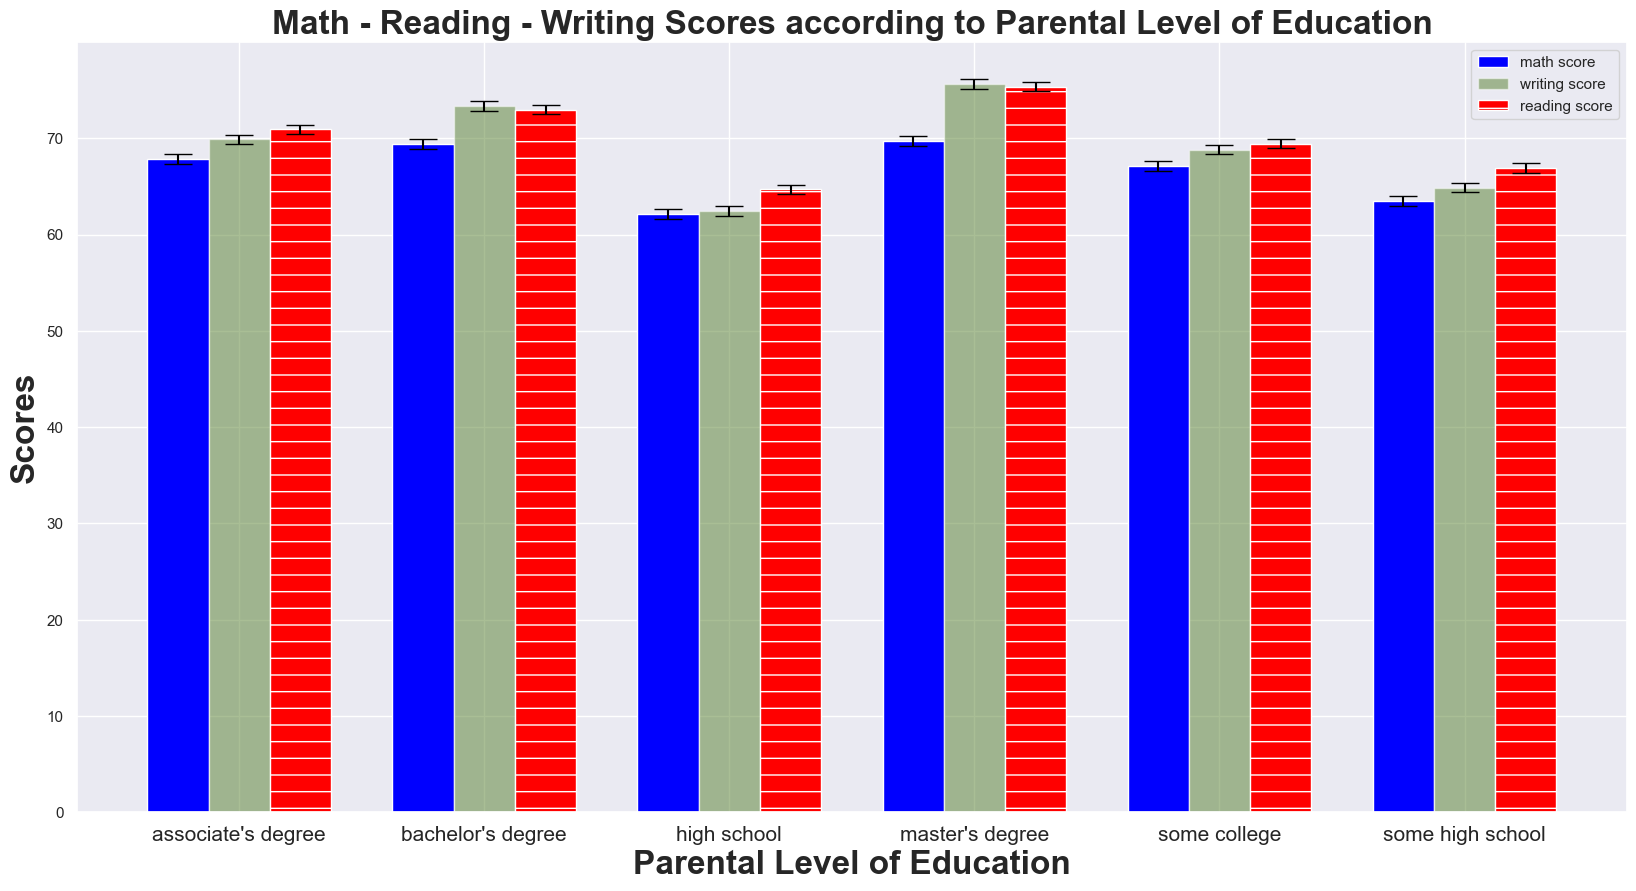

In [47]:
race_math = dataset[["parental level of education","math score"]].groupby(["parental level of education"], as_index = False).mean()
race_writing = dataset[["parental level of education","writing score"]].groupby(["parental level of education"], as_index = False).mean()
race_reading = dataset[["parental level of education","reading score"]].groupby(["parental level of education"], as_index = False).mean()

plt.figure(figsize=(20,10))
plt.title('Math - Reading - Writing Scores according to Parental Level of Education', fontweight='bold', size = 24)

barWidth = 0.25
 
bars1 = race_math['math score']
bars2 = race_writing['writing score']
bars3 = race_reading['reading score']
 
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
 
plt.bar(r1, bars1, color='blue', width=barWidth, edgecolor='white', label='math score', yerr=0.5,ecolor="black",capsize=10)
plt.bar(r2, bars2, color='#557f2d', width=barWidth, edgecolor='white', label='writing score', yerr=0.5,ecolor="black",capsize=10, alpha = .50)
plt.bar(r3, bars3, color='red', width=barWidth, edgecolor='white', label='reading score', yerr=0.5,ecolor="black",capsize=10, hatch = '-')
 
modelNames = race_math['parental level of education']
    
plt.xlabel('Parental Level of Education', fontweight='bold', size = 24)
plt.ylabel('Scores', fontweight='bold', size = 24)
plt.xticks([r + barWidth for r in range(len(bars1))], modelNames, rotation = 0, size = 15)
 
plt.legend()
plt.show()

parental level of education:

some college 226

associate's degree 222

high school 196

some high school 179

bachelor's degree 118

master's degree 59

!!! When parental education levels are evaluated; It is seen that the average of students whose parents have completed a Master is the highest in all tests. The lowest averages are those whose parents have High school degree. However, here, too, it is necessary to consider the size of the sample set. While there are 59 samples in Master's Degree, there are 196 samples in the 'High School' set. !!!

**lunch**

In [48]:
dataset[["lunch","math score"]].groupby(["lunch"], as_index = False).mean().sort_values(by="math score",ascending = False)

,lunch,math score
1,standard,70.034109
0,free/reduced,58.921127


In [49]:
dataset[["lunch","reading score"]].groupby(["lunch"], as_index = False).mean().sort_values(by="reading score",ascending = False)

,lunch,reading score
1,standard,71.654264
0,free/reduced,64.653521


In [50]:
dataset[["lunch","writing score"]].groupby(["lunch"], as_index = False).mean().sort_values(by="writing score",ascending = False)

,lunch,writing score
1,standard,70.823256
0,free/reduced,63.022535


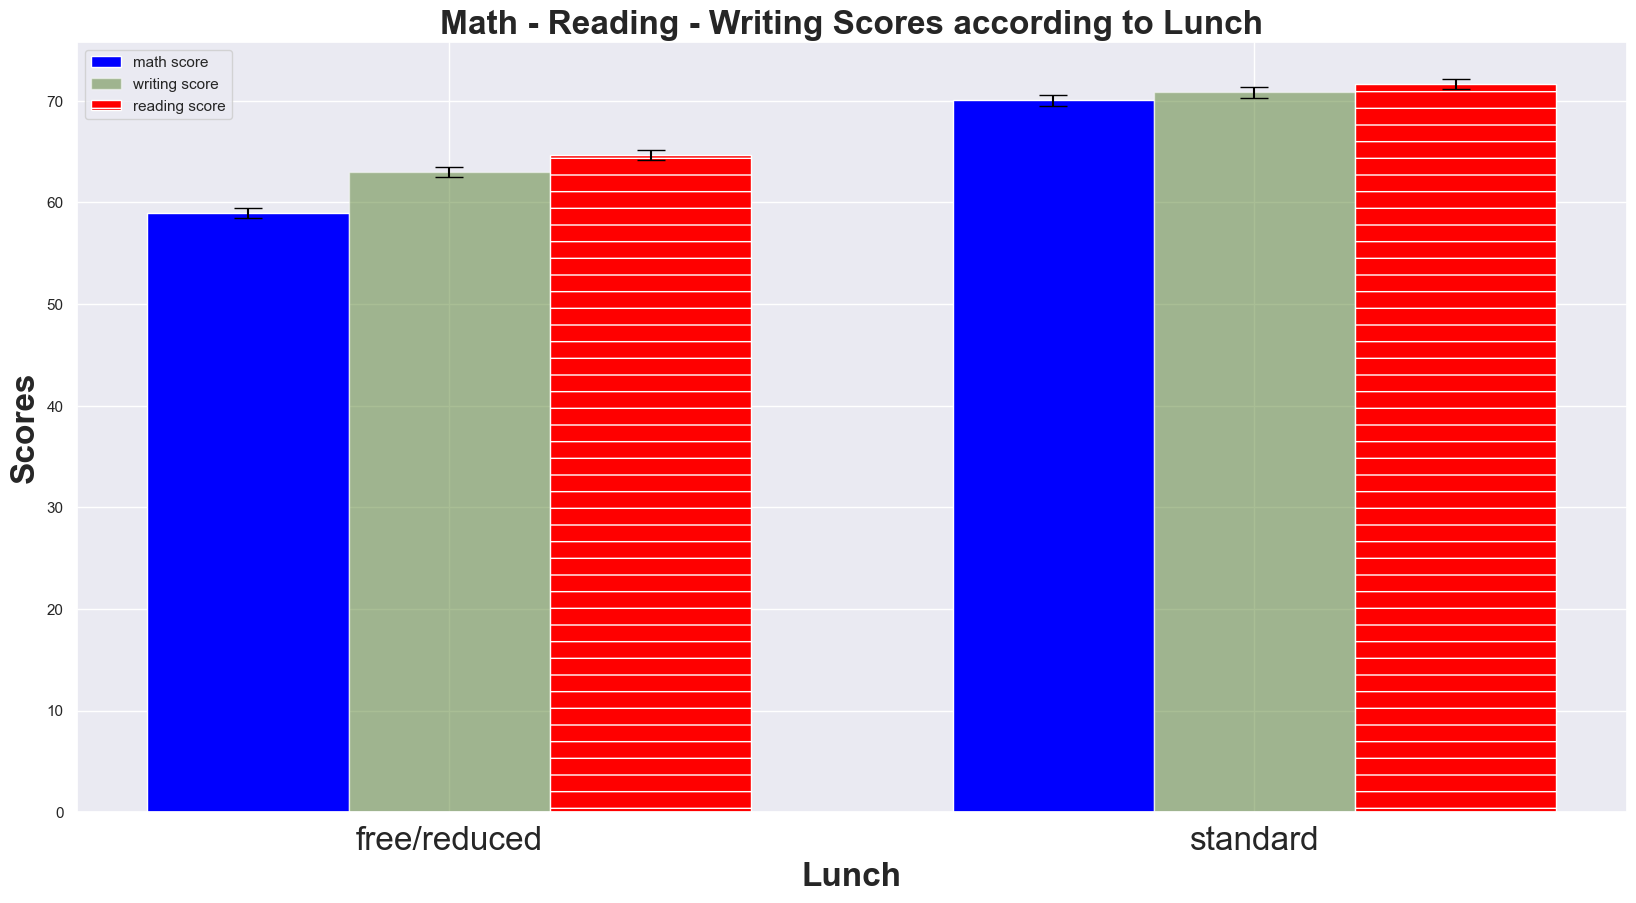

In [51]:
race_math = dataset[["lunch","math score"]].groupby(["lunch"], as_index = False).mean()
race_writing = dataset[["lunch","writing score"]].groupby(["lunch"], as_index = False).mean()
race_reading = dataset[["lunch","reading score"]].groupby(["lunch"], as_index = False).mean()

plt.figure(figsize=(20,10))
plt.title('Math - Reading - Writing Scores according to Lunch', fontweight='bold', size = 24)

barWidth = 0.25
 
bars1 = race_math['math score']
bars2 = race_writing['writing score']
bars3 = race_reading['reading score']
 
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
 
plt.bar(r1, bars1, color='blue', width=barWidth, edgecolor='white', label='math score', yerr=0.5,ecolor="black",capsize=10)
plt.bar(r2, bars2, color='#557f2d', width=barWidth, edgecolor='white', label='writing score', yerr=0.5,ecolor="black",capsize=10, alpha = .50)
plt.bar(r3, bars3, color='red', width=barWidth, edgecolor='white', label='reading score', yerr=0.5,ecolor="black",capsize=10, hatch = '-')
 
modelNames = race_math['lunch']
    
plt.xlabel('Lunch', fontweight='bold', size = 24)
plt.ylabel('Scores', fontweight='bold', size = 24)
plt.xticks([r + barWidth for r in range(len(bars1))], modelNames, rotation = 0, size = 24)
 
plt.legend()
plt.show()

**Insights:**¶

lunch:

standard 645

free/reduced 355

!!! The 'standard' ones in the 'lunch' feature appear to be more successful than the 'free/reduced' ones. It seems that the biggest difference is in the 'math score'. !!!

**test preparation course**

In [52]:
dataset[["test preparation course","math score"]].groupby(["test preparation course"], as_index = False).mean().sort_values(by="math score",ascending = False)

,test preparation course,math score
0,completed,69.695531
1,none,64.077882


In [53]:
dataset[["test preparation course","reading score"]].groupby(["test preparation course"], as_index = False).mean().sort_values(by="reading score",ascending = False)

,test preparation course,reading score
0,completed,73.893855
1,none,66.534268


In [54]:
dataset[["test preparation course","writing score"]].groupby(["test preparation course"], as_index = False).mean().sort_values(by="writing score",ascending = False)

,test preparation course,writing score
0,completed,74.418994
1,none,64.504673


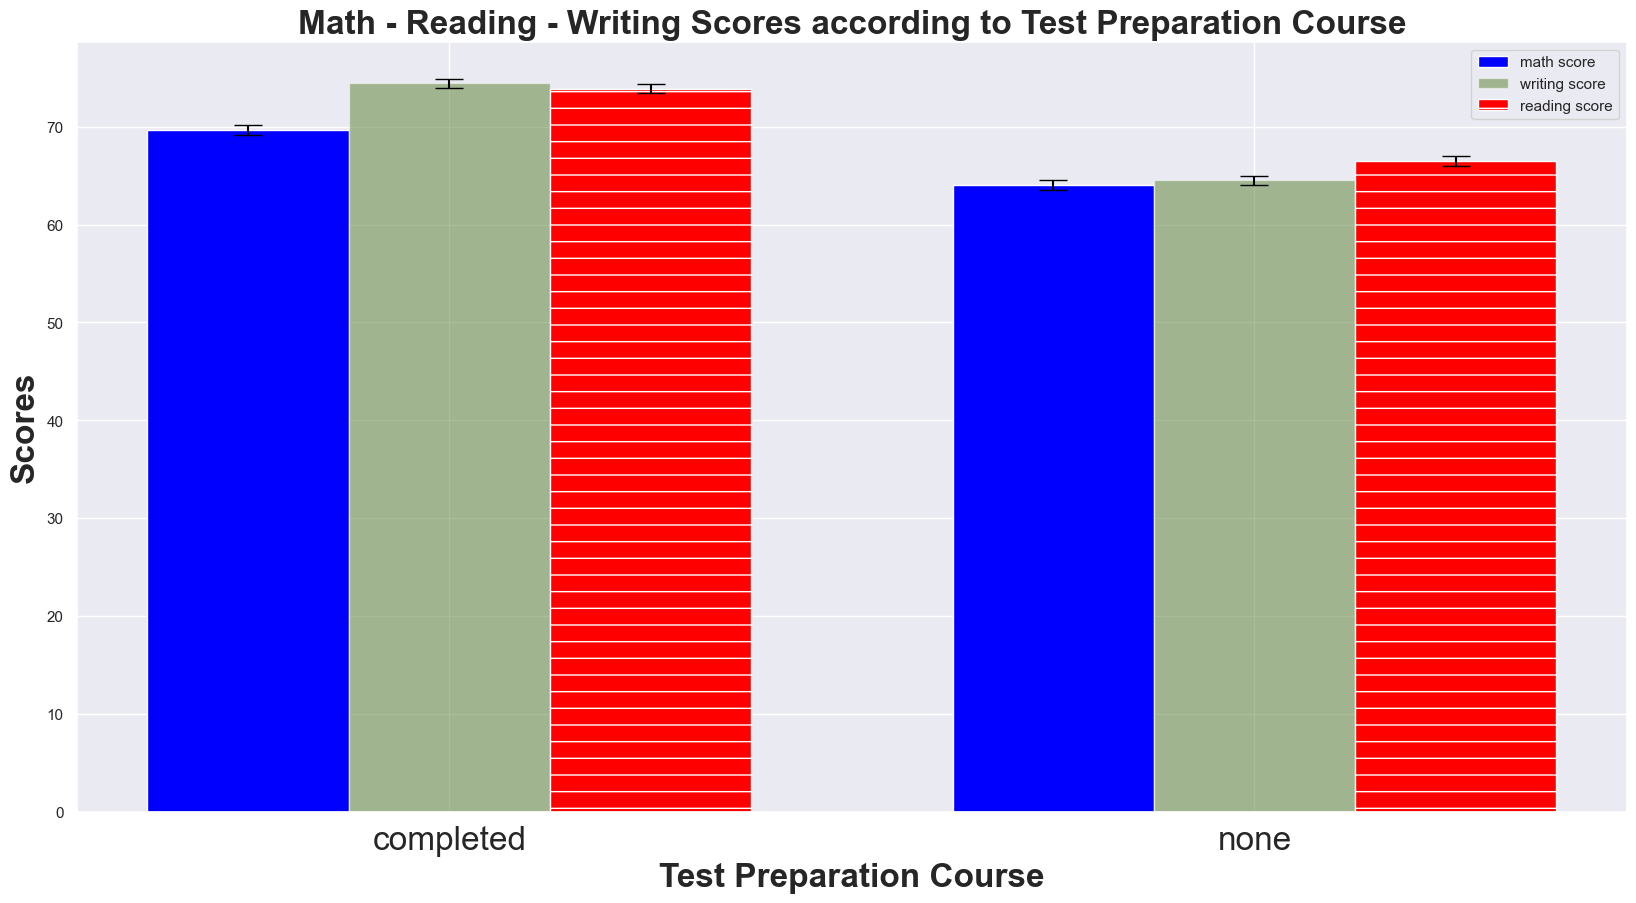

In [55]:
race_math = dataset[["test preparation course","math score"]].groupby(["test preparation course"], as_index = False).mean()
race_writing = dataset[["test preparation course","writing score"]].groupby(["test preparation course"], as_index = False).mean()
race_reading = dataset[["test preparation course","reading score"]].groupby(["test preparation course"], as_index = False).mean()

plt.figure(figsize=(20,10))
plt.title('Math - Reading - Writing Scores according to Test Preparation Course', fontweight='bold', size = 24)

barWidth = 0.25
 
bars1 = race_math['math score']
bars2 = race_writing['writing score']
bars3 = race_reading['reading score']
 
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
 
plt.bar(r1, bars1, color='blue', width=barWidth, edgecolor='white', label='math score', yerr=0.5,ecolor="black",capsize=10)
plt.bar(r2, bars2, color='#557f2d', width=barWidth, edgecolor='white', label='writing score', yerr=0.5,ecolor="black",capsize=10, alpha = .50)
plt.bar(r3, bars3, color='red', width=barWidth, edgecolor='white', label='reading score', yerr=0.5,ecolor="black",capsize=10, hatch = '-')
 
modelNames = race_math['test preparation course']
    
plt.xlabel('Test Preparation Course', fontweight='bold', size = 24)
plt.ylabel('Scores', fontweight='bold', size = 24)
plt.xticks([r + barWidth for r in range(len(bars1))], modelNames, rotation = 0, size = 24)
 
plt.legend()
plt.show()

**Insights**

test preparation course:

none 642

completed 358

!!! It seems that those who complete the test preparation course are more successful than those who do not. !!!

**Anomaly Detection**

Anomaly is one that differs / deviates significantly from other observations in the same sample. An anomaly detection pattern produces two different results. The first is a categorical tag for whether the observation is abnormal or not; the second is a score or trust value. Score carries more information than the label. Because it also tells us how abnormal the observation is. The tag just tells you if it's abnormal. While labeling is more common in supervised methods, the score is more common in unsupervised and semisupervised methods.

In [56]:
def detect_outliers(df,features):
    outlier_indices = []
    
    for c in features:
        # 1st quartile
        Q1 = np.percentile(df[c],25)
        # 3rd quartile
        Q3 = np.percentile(df[c],75)
        # IQR
        IQR = Q3 - Q1
        # Outlier step
        outlier_step = IQR * 1.5
        # detect outlier and their indeces
        outlier_list_col = df[(df[c] < Q1 - outlier_step) | (df[c] > Q3 + outlier_step)].index
        # store indeces
        outlier_indices.extend(outlier_list_col)
    
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2)
    
    return multiple_outliers

In [57]:
dataset.loc[detect_outliers(dataset,['math score', 'reading score', 'writing score'])]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10
980,female,group B,high school,free/reduced,none,8,24,23


**Visualization**

**Pie Plot**

Pie Charts help show proportions and percentages across categories by dividing a circle into proportional parts. Each arc length represents a proportion of each category, while the full circle represents the sum of all data equal to 100%. Pie charts are ideal for giving the reader a quick idea of the proportional distribution of the data.

Text(0.5, 1.0, 'Distribution of Students by Races')

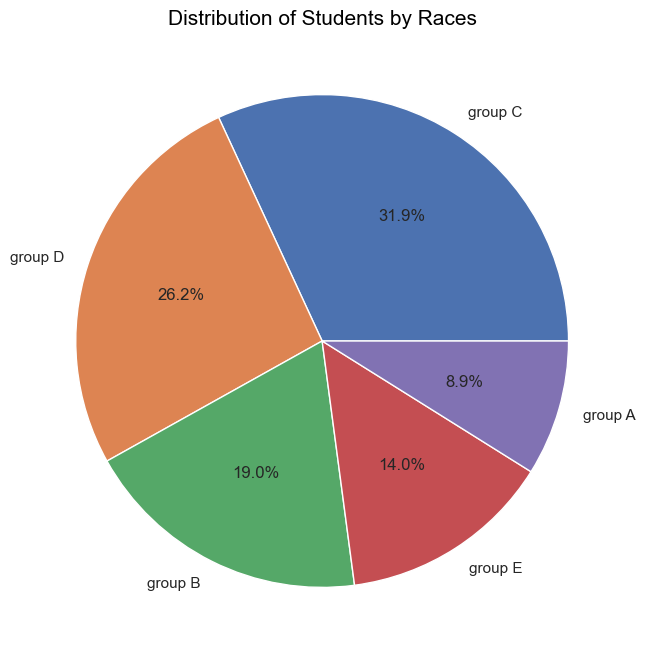

In [58]:
labels = dataset['race/ethnicity'].value_counts().index
sizes = dataset['race/ethnicity'].value_counts().values

plt.figure(figsize = (8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Students by Races',color = 'black',fontsize = 15)

Text(0.5, 1.0, 'Distribution of Students by Genders')

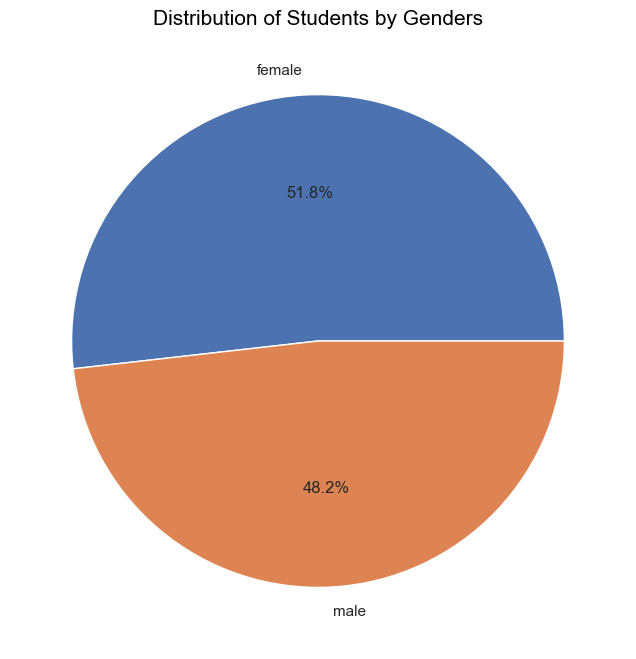

In [59]:
labels = dataset['gender'].value_counts().index
sizes = dataset['gender'].value_counts().values

plt.figure(figsize = (8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Students by Genders',color = 'black',fontsize = 15)

<Axes: xlabel='gender', ylabel='writing score'>

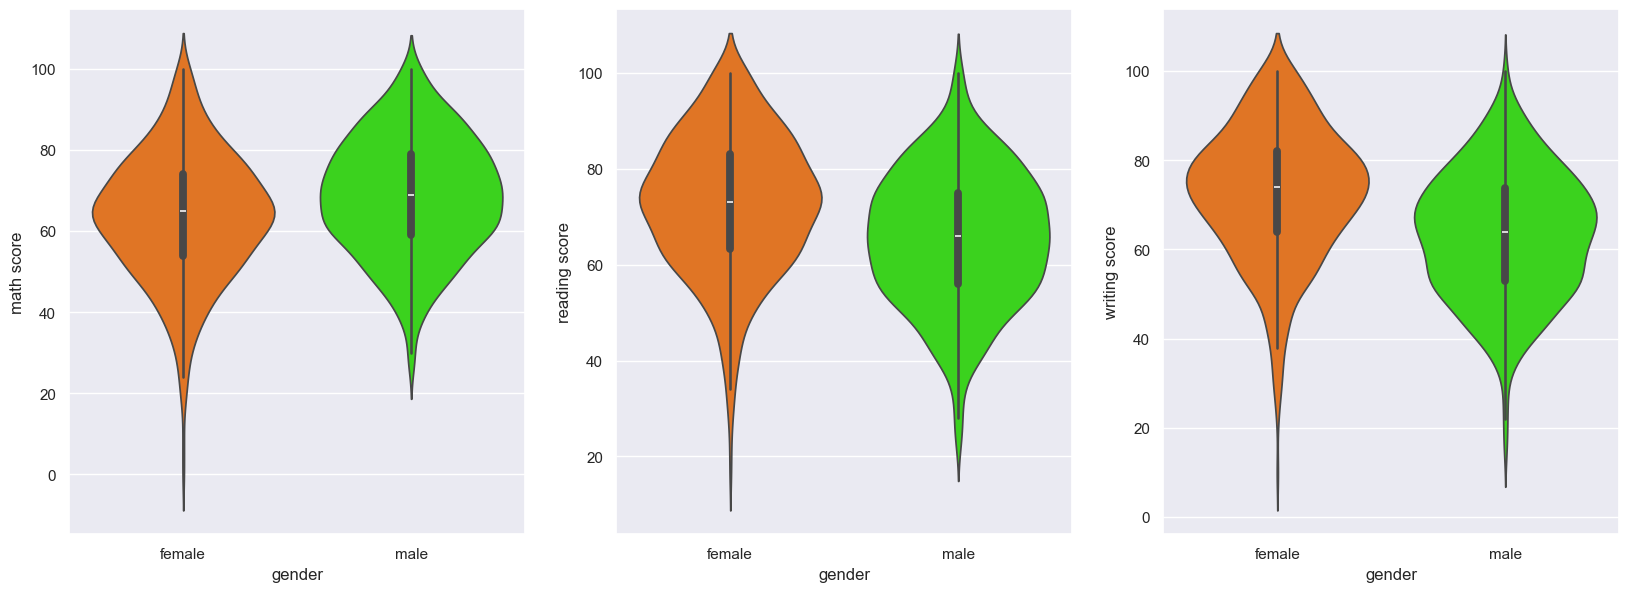

In [60]:
plt.figure(figsize=(20,15))
sns.set_theme(style="darkgrid")
plt.subplot(2,3,1)
sns.violinplot(x = 'gender', y = 'math score', data = dataset, palette="gist_ncar_r")
plt.subplot(2,3,2)
sns.violinplot(x = 'gender', y = 'reading score', data = dataset, palette="gist_ncar_r")
plt.subplot(2,3,3)
sns.violinplot(x = 'gender', y = 'writing score', data = dataset, palette="gist_ncar_r")

**Insights**

With these graphs, we see the distribution of the scores of men and women.

For the Math Score: Bloating is in almost the same location, but female show a line to under 20. It ends around 20 in male.
For Reading Score: There is an accumulation of 70-80 in females. In males, the notes are more evenly spread.
For Writing Score: It can be seen that the average of females is significantly higher than that of males.

<Axes: xlabel='lunch', ylabel='writing score'>

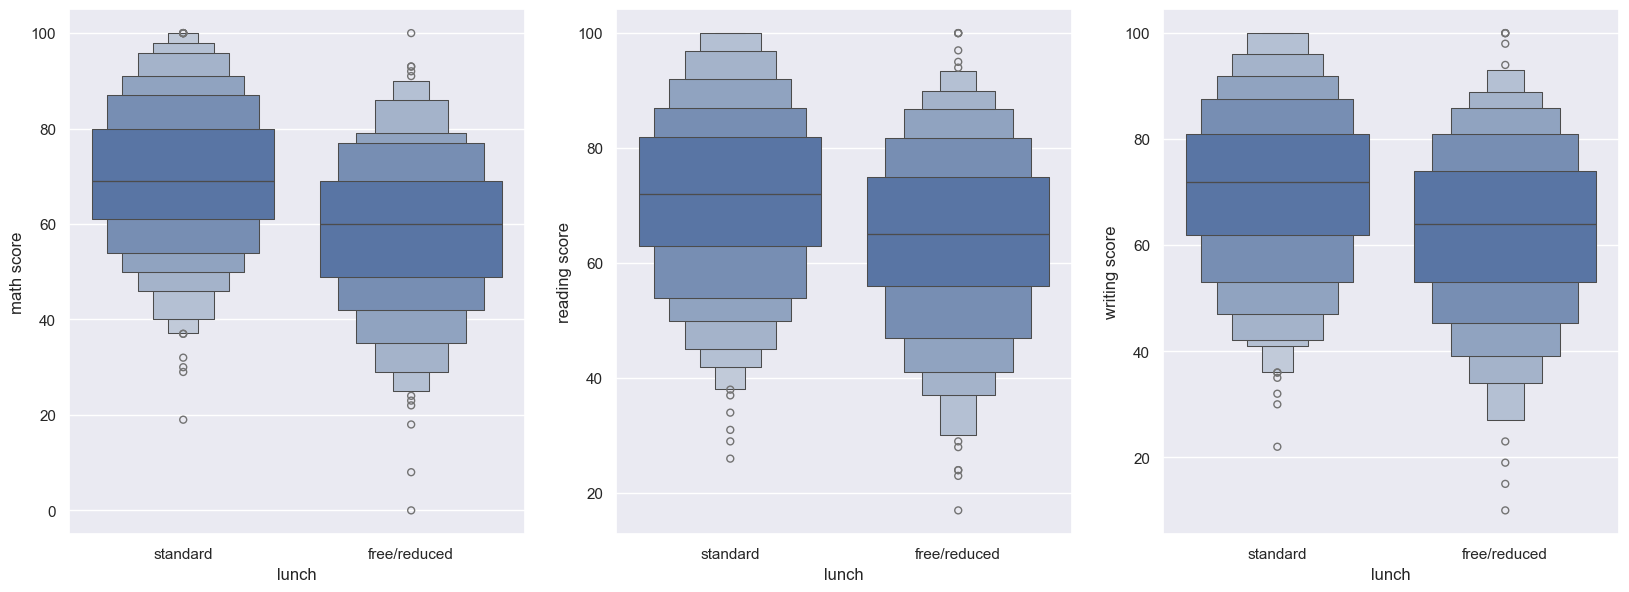

In [61]:
import seaborn as sns
sns.set_theme(style="darkgrid")


plt.figure(figsize=(20,15))

plt.subplot(2,3,1)
sns.boxenplot(x=dataset['lunch'], y=dataset['math score'],
              color="b", 
              scale="linear", data=dataset)

plt.subplot(2,3,2)
sns.boxenplot(x=dataset['lunch'], y=dataset['reading score'],
              color="b", 
              scale="linear", data=dataset)

plt.subplot(2,3,3)
sns.boxenplot(x=dataset['lunch'], y=dataset['writing score'],
              color="b", 
              scale="linear", data=dataset)

These plots show the change of the Score according to the 'lunch' feature. In general, the 'standard' ones appear to have higher scores.

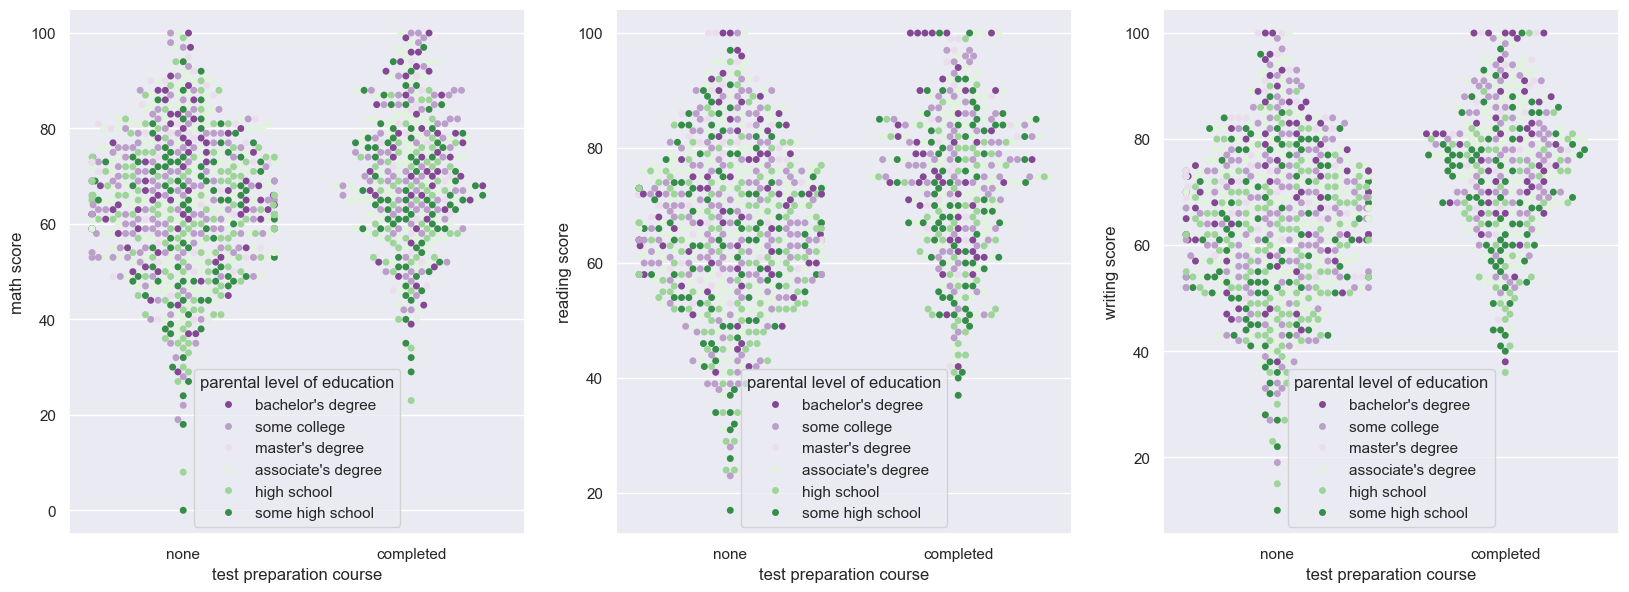

In [62]:
import seaborn as sns
sns.set_theme(style="darkgrid")

plt.figure(figsize=(20,15))

plt.subplot(2,3,1)
sns.swarmplot(x="test preparation course", y="math score",hue="parental level of education", data=dataset, palette="PRGn")

plt.subplot(2,3,2)
sns.swarmplot(x="test preparation course", y="reading score",hue="parental level of education", data=dataset, palette="PRGn")

plt.subplot(2,3,3)
sns.swarmplot(x="test preparation course", y="writing score",hue="parental level of education", data=dataset, palette="PRGn")

plt.show()

In these graphs, the distribution of Scores according to the 'test preparation course' feature can be seen. At the same time, the education level of the students' families is also seen. We got an image similar to the one we got on Violin Plot. However, with the 'hue' parameter used in swarmplot, we made the plot 3-dimensional.

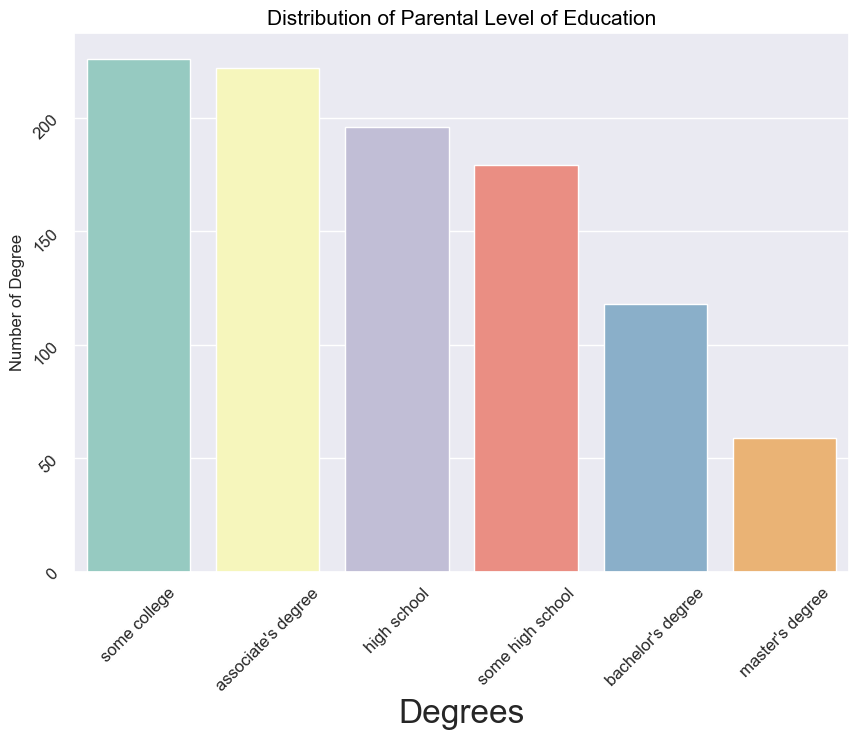

In [63]:
counts = dataset['parental level of education'].value_counts()

plt.figure(figsize=(10,7))
sns.barplot(x=counts.index, y=counts.values, palette="Set3")

plt.ylabel('Number of Degree')
plt.xlabel('Degrees', style = 'normal', size = 24)

plt.xticks(rotation = 45, size = 12)
plt.yticks(rotation = 45, size = 12)

plt.title('Distribution of Parental Level of Education',color = 'black',fontsize=15)
plt.show()

This chart shows the distribution of the Parental Level of Education.

In [79]:
dataset['overall'] = (dataset['math score'] + dataset['reading score'] + dataset['writing score'])/3

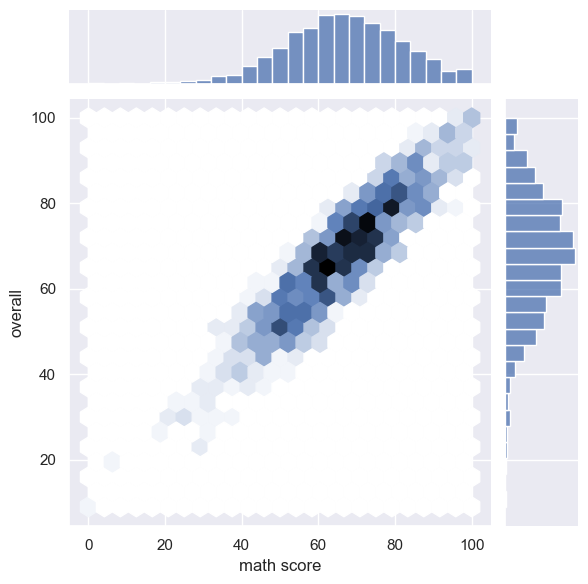

In [66]:
sns.set_theme(style="darkgrid")
g = sns.jointplot(x = dataset['math score'], y = dataset['overall'], kind = 'hex')
plt.show()

As expected, there is a linear relationship between the overall - math score. It is observed that the largest concentration is between 60-80.

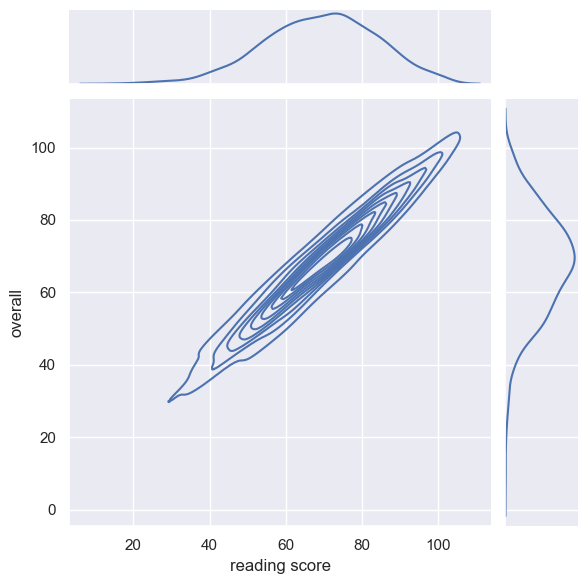

In [67]:
sns.set_theme(style="darkgrid")
g = sns.jointplot(x = dataset['reading score'], y = dataset['overall'], kind="kde", size=7)
plt.show()

Another kind of Joint Plot. The points where the lines are concentrated show that there are more students in that grade range. Between 60-80.

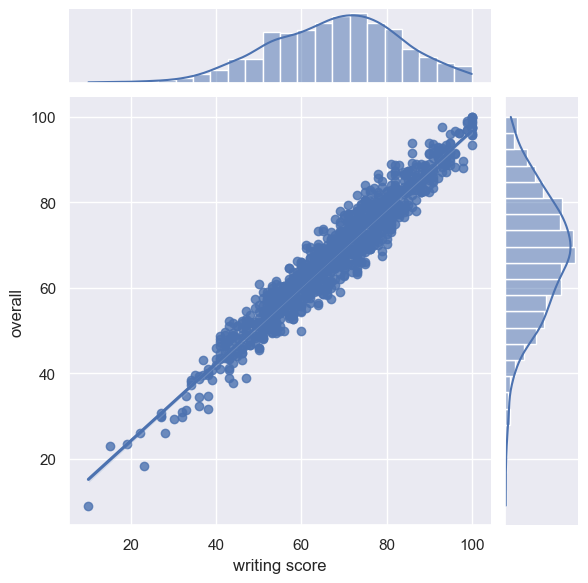

In [69]:
sns.set_theme(style="darkgrid")
g = sns.jointplot(x = dataset['writing score'], y = dataset['overall'], kind="reg")
plt.show()

In this graph, as in the others, a linear increase is observed between 'overall' and any Score value. The distribution of students seems balanced between 50-85.

**correlation**

In [80]:
dataset1 = dataset[['math score', 'reading score','writing score', 'overall']]

In [81]:
dataset1.corr()

,math score,reading score,writing score,overall
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
overall,0.918746,0.970331,0.965667,1.000000


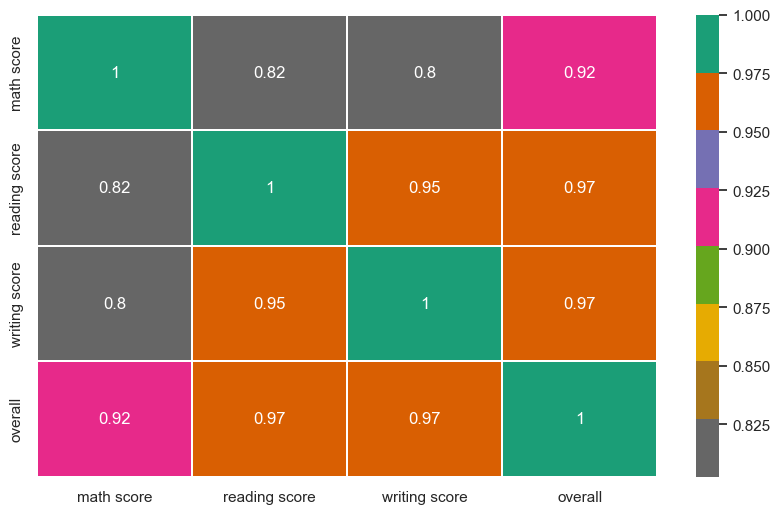

In [82]:
plt.figure(figsize=(10,6)) 
sns.heatmap(dataset1.corr(), annot=True, cmap='Dark2_r', linewidths = .2)
plt.show()

Correlated features are seen in this Heat Map. We have already created the variable 'overall'. Increasing any value will increase 'overall' anyway. It can be deduced from the chart that there is a positive correlation between reading and writing.

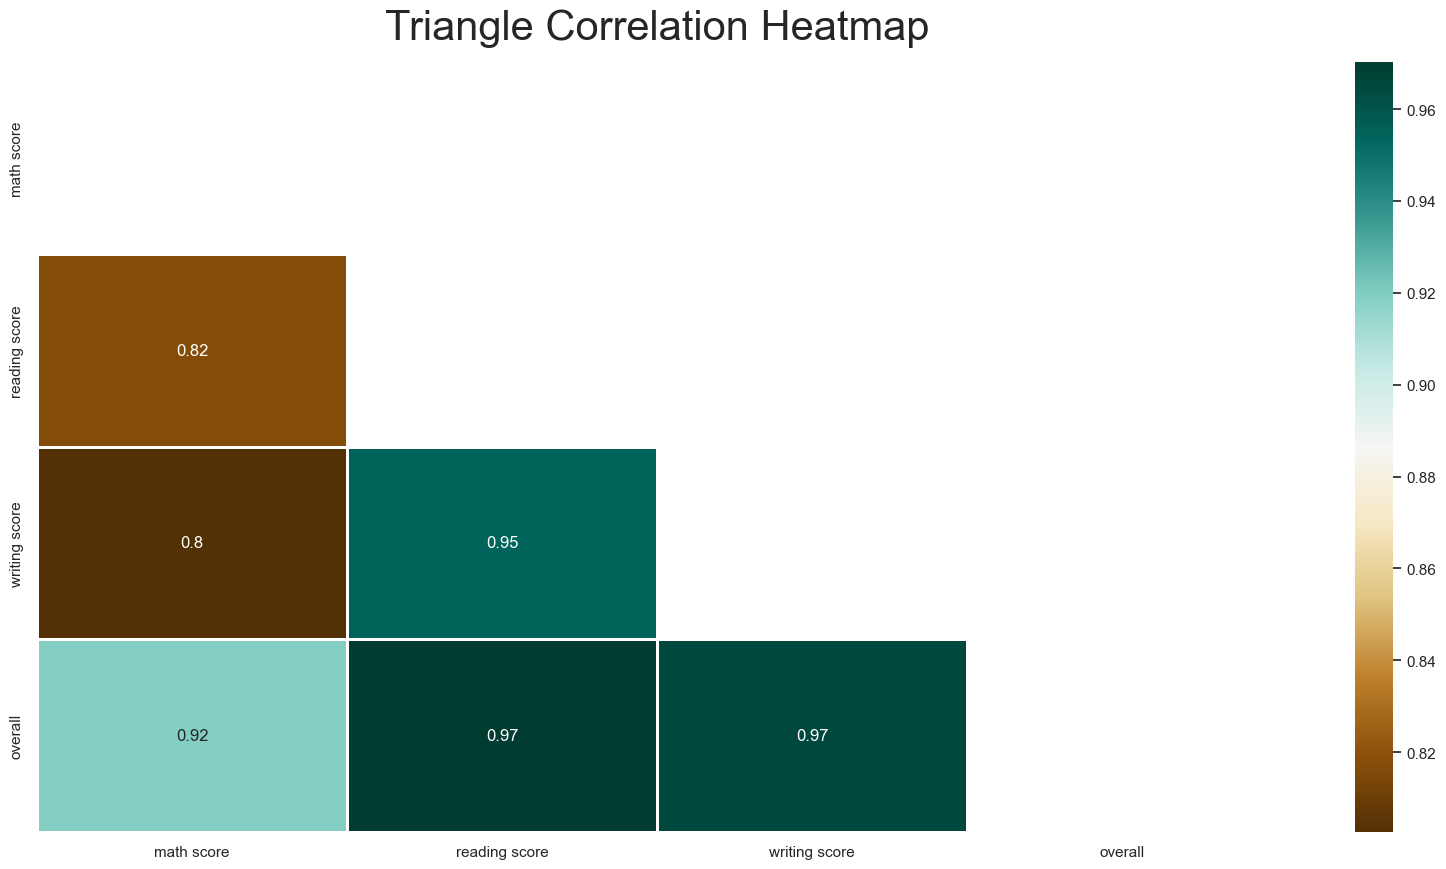

In [83]:
plt.figure(figsize=(20, 10))
sns.set_style('white')
mask = np.triu(np.ones_like(dataset1.corr(), dtype=np.bool))
heatmap = sns.heatmap(dataset1.corr(), mask=mask,annot=True, cmap='BrBG', linewidths = 2)
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':30}, pad=16);

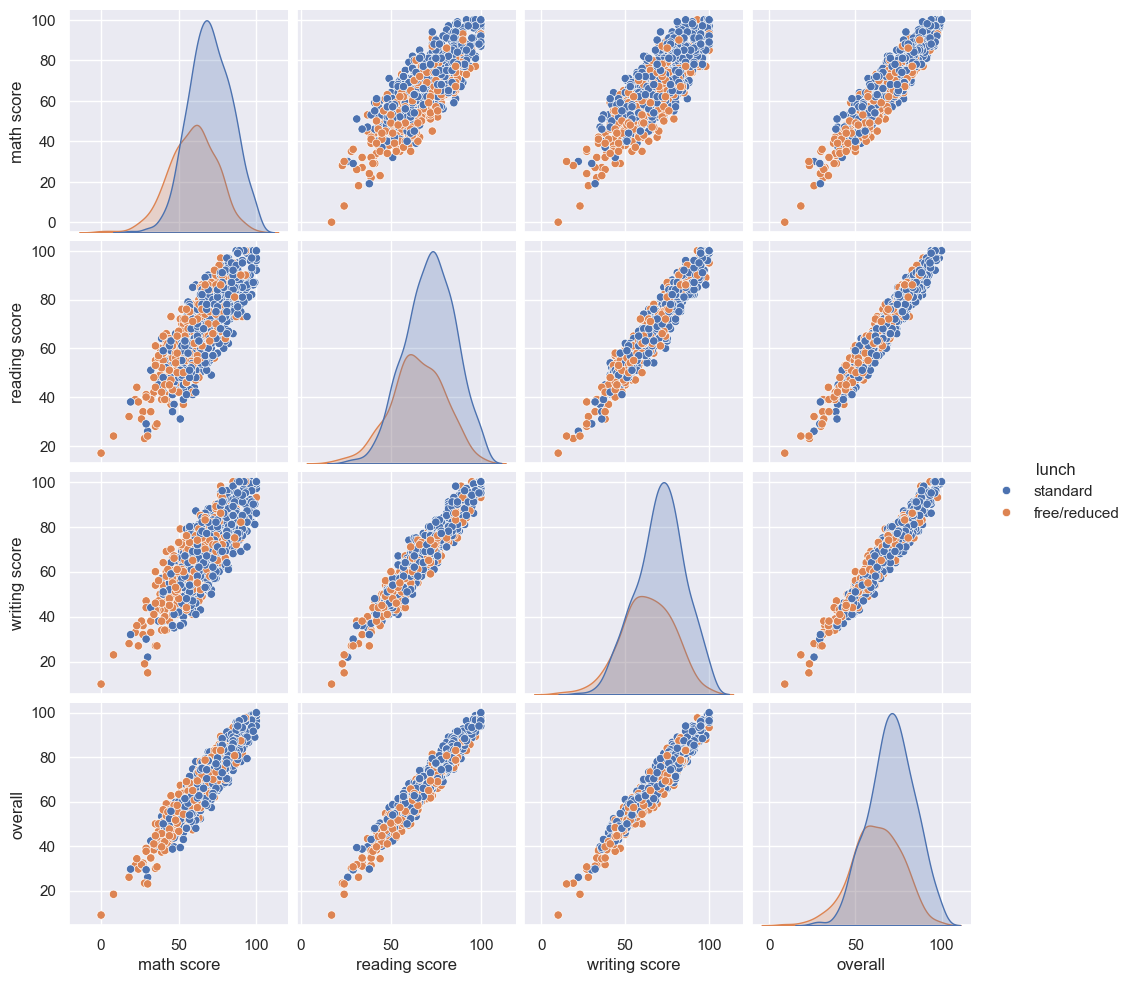

In [84]:
sns.set_theme(style="darkgrid")
sns.pairplot(dataset, hue="lunch")

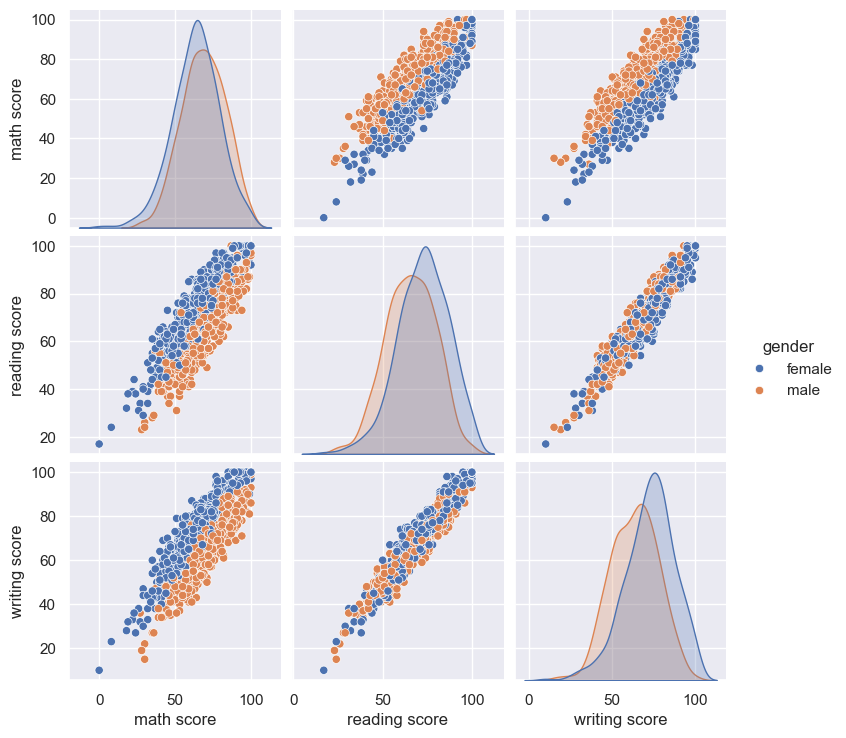

In [9]:
sns.set_theme(style="darkgrid")
sns.pairplot(dataset, hue="gender")

**What conclusion can be drawn from this graph?**

As we have reached in previous plots and reviews, students with 'lunch' = 'standard' generally do better than others.

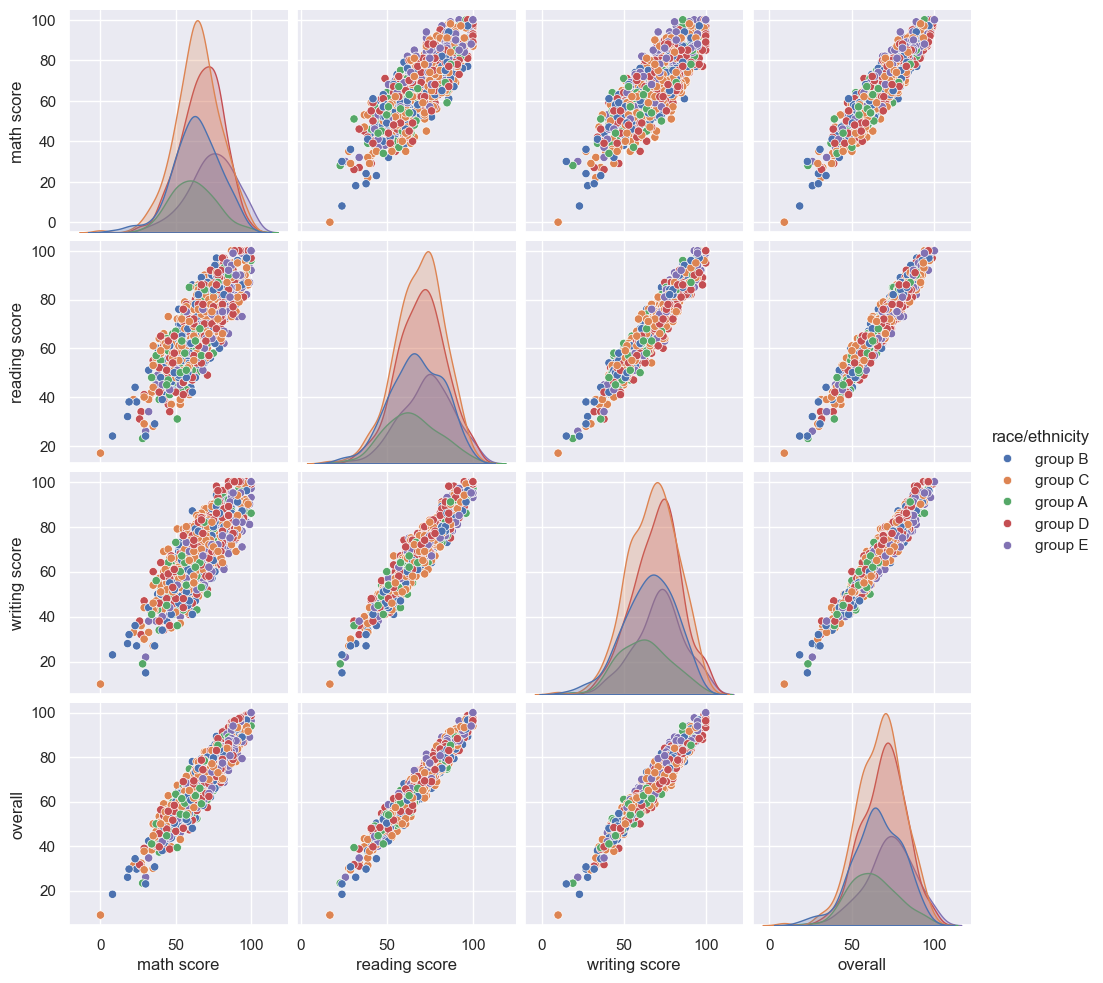

In [85]:
sns.pairplot(dataset, hue="race/ethnicity")

These graphs are difficult to interpret as there are five options for 'race / ethnicity'. There is no clear distinction between points. I think using two and a maximum of three categories for the Pair Plot will make it easier to interpret.

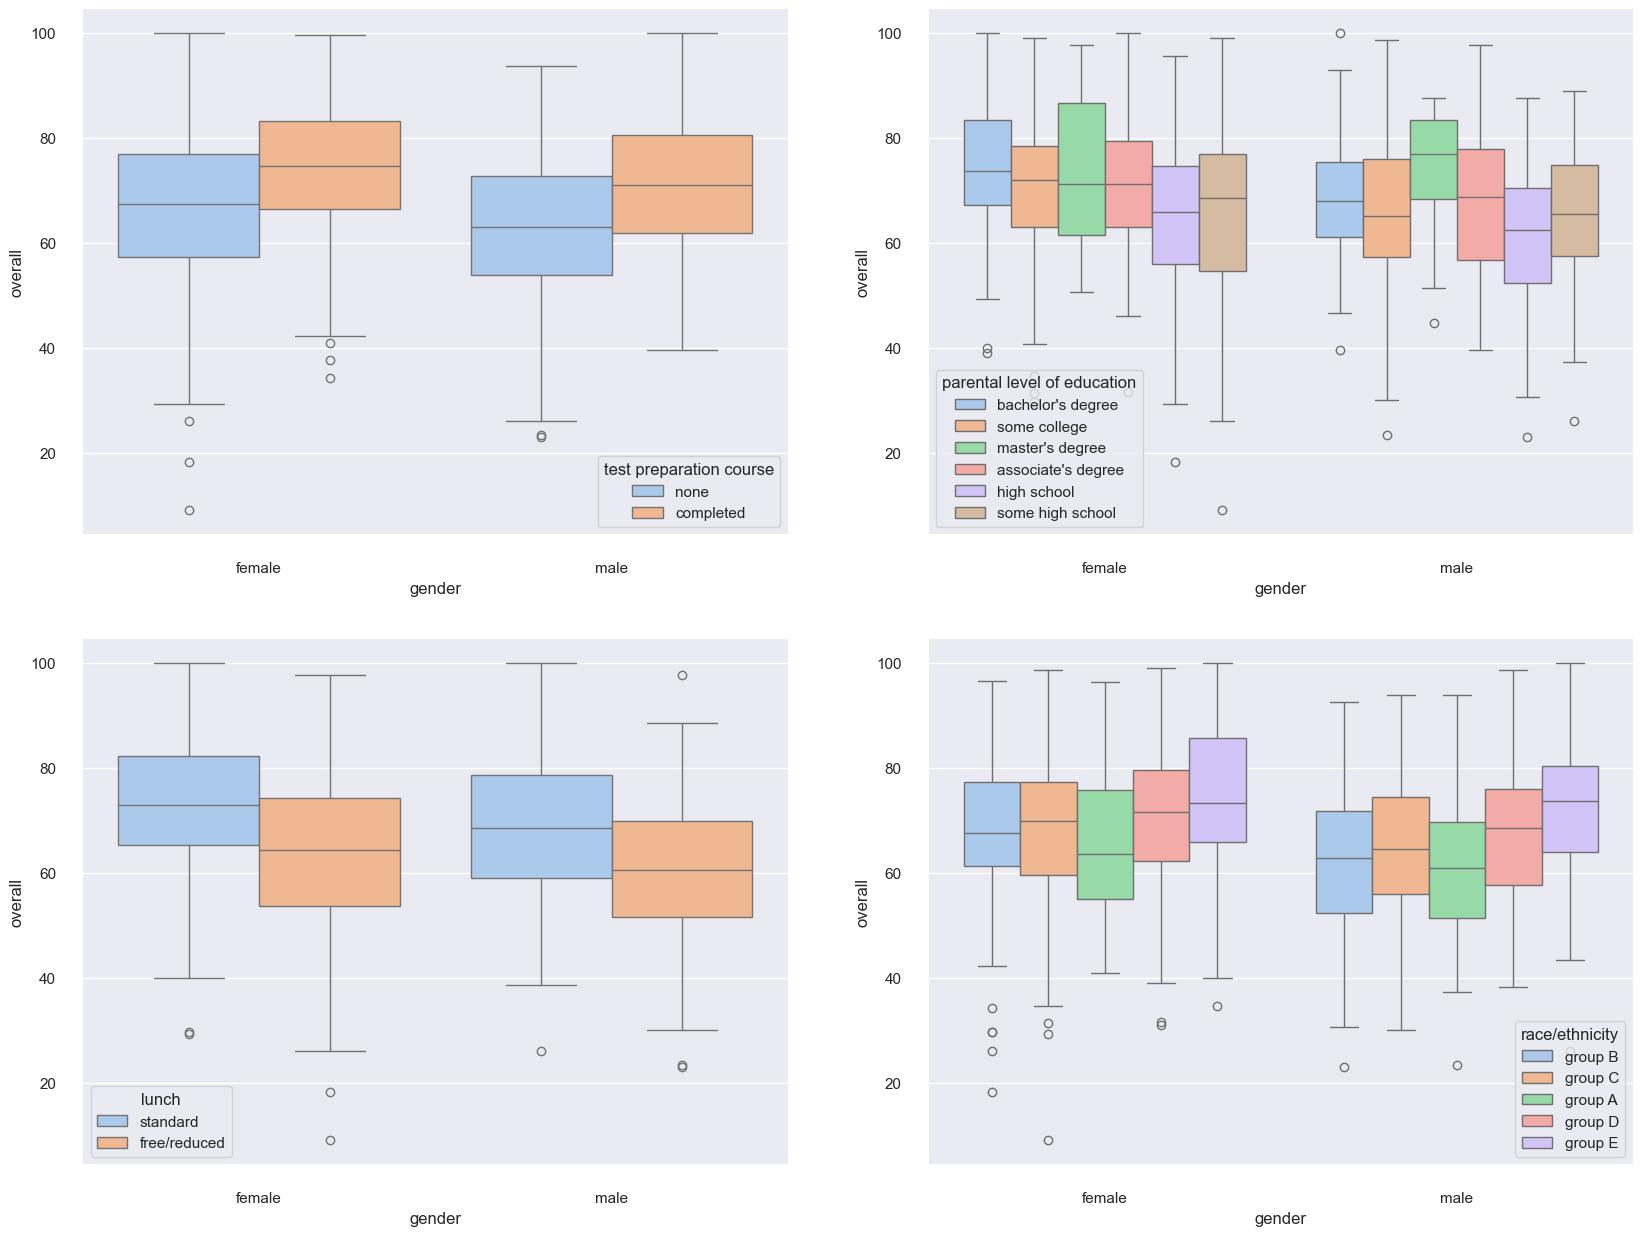

In [86]:
sns.set_theme(style="darkgrid", palette="pastel")

plt.figure(figsize=(20,15))

plt.subplot(2,2,1)
sns.boxplot(x="gender", y="overall", hue="test preparation course", data=dataset)

plt.subplot(2,2,2)
sns.boxplot(x="gender", y="overall", hue="parental level of education", data=dataset)

plt.subplot(2,2,3)
sns.boxplot(x="gender", y="overall", hue="lunch", data=dataset)

plt.subplot(2,2,4)
sns.boxplot(x="gender", y="overall", hue="race/ethnicity", data=dataset)

sns.despine(offset=10, trim=True)
plt.show()

* For females: 'test preparation course' = 'completed' and 'parental level of education' = 'master's degree' and 'lunch' = 'standard' and 'race / ethnicity' = 'group E' values can be shown as factors that increase success.

* For males: 'test preparation course' = 'completed' and 'parental level of education' = 'master's degree' and 'lunch' = 'standard' and 'race / ethnicity' = 'group E' values can be shown as factors that increase success.

Since all values are equal for males and females, they can be cited as factors that increase the success of any student.

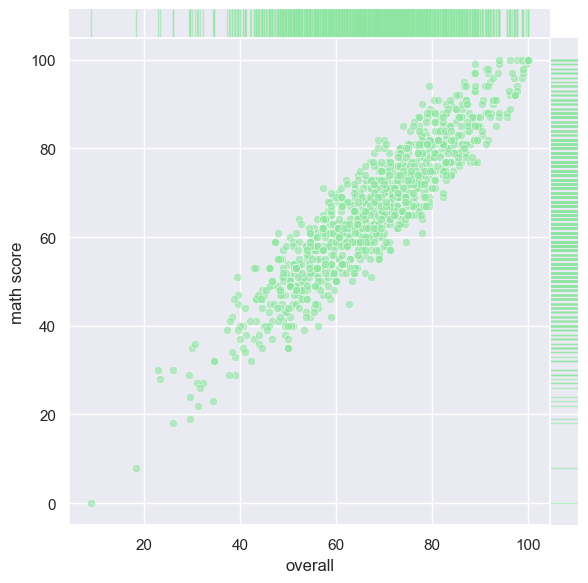

In [87]:
g = sns.JointGrid(data=dataset, x="overall", y="math score", space=0, ratio=17)
g.plot_joint(sns.scatterplot, color="g", alpha=.6, legend=False)
g.plot_marginals(sns.rugplot, height=1, color="g", alpha=.6)

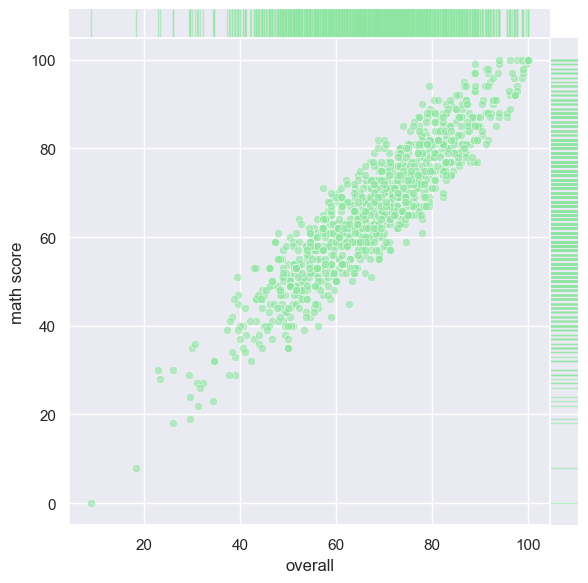

In [88]:
g = sns.JointGrid(data=dataset, x="overall", y="math score", space=0, ratio=17)
g.plot_joint(sns.scatterplot, color="g", alpha=.6, legend=False)
g.plot_marginals(sns.rugplot, height=1, color="g", alpha=.6)

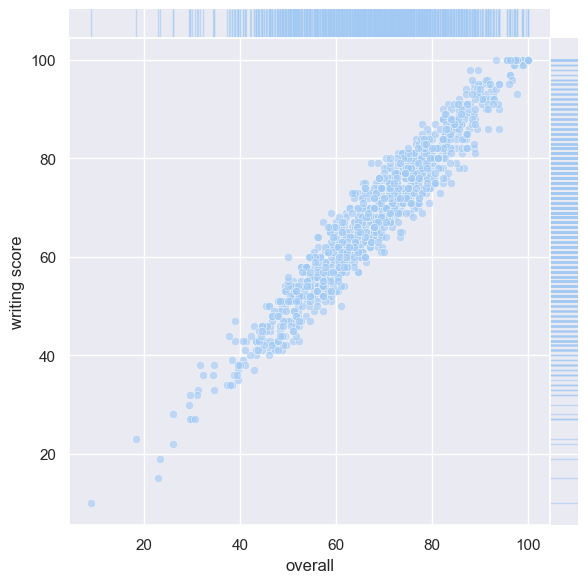

In [89]:
g = sns.JointGrid(data=dataset, x="overall", y="writing score", space=0, ratio=17)
g.plot_joint(sns.scatterplot, color="b", alpha=.6, legend=False)
g.plot_marginals(sns.rugplot, height=1, color="b", alpha=.6)

In these plots, we got an image similar to Joint Plot. But differently, we can see the density through the lines formed parallel to the x and y axes.

<Axes: xlabel='overall', ylabel='math score'>

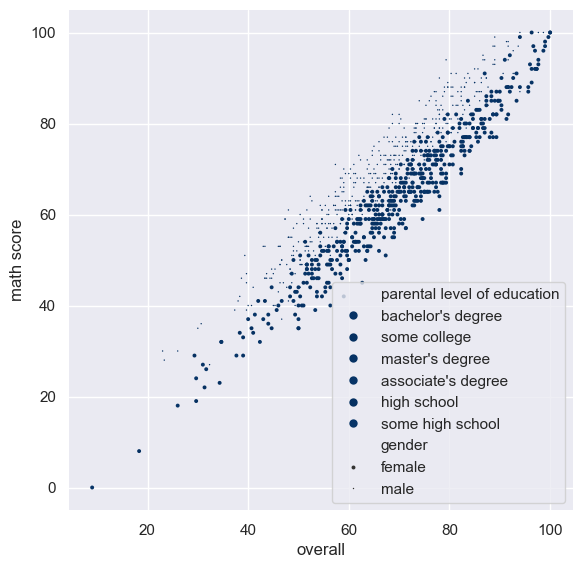

In [90]:
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
sns.set_theme(style="darkgrid")
sns.scatterplot(x=dataset['overall'], y=dataset['math score'],
                hue=dataset['parental level of education'], 
                size="gender",
                palette="RdBu",
                hue_order=dataset['parental level of education'],
                sizes=(1, 8), 
                linewidth=0,
                data=dataset, ax=ax)

<Axes: xlabel='overall', ylabel='writing score'>

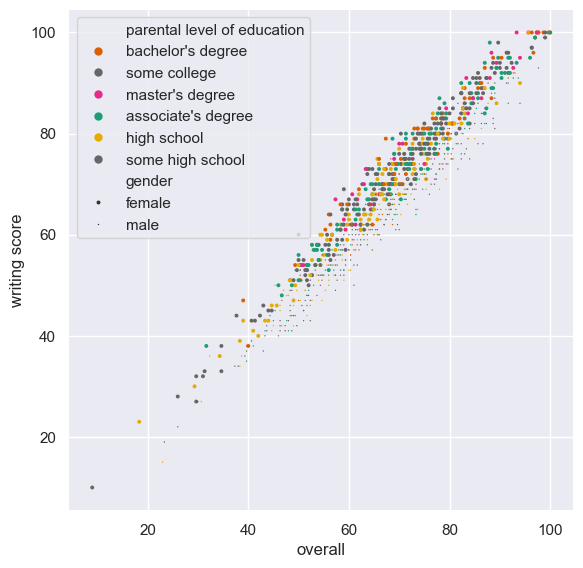

In [91]:
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
sns.set_theme(style="darkgrid")
sns.scatterplot(x=dataset['overall'], y=dataset['writing score'],
                hue=dataset['parental level of education'], 
                size="gender",
                palette="Dark2",
                hue_order=dataset['parental level of education'],
                sizes=(1, 8), 
                linewidth=0,
                data=dataset, ax=ax)

<Axes: xlabel='overall', ylabel='reading score'>

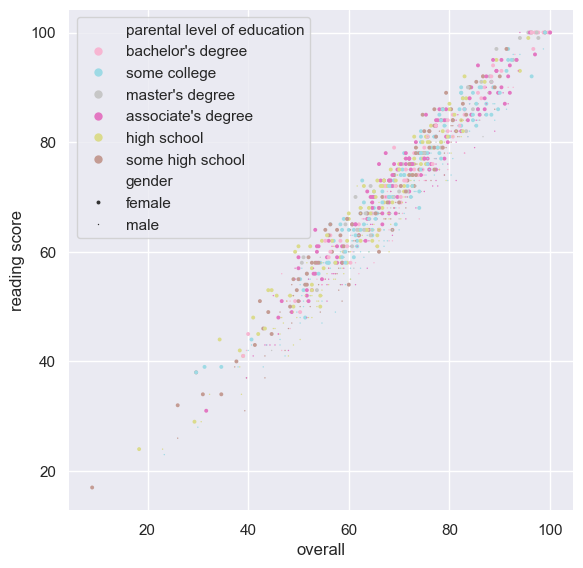

In [92]:
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
sns.set_theme(style="darkgrid")
sns.scatterplot(x=dataset['overall'], y=dataset['reading score'],
                hue=dataset['parental level of education'], 
                size="gender",
                palette="tab20",
                hue_order=dataset['parental level of education'],
                sizes=(1, 8), 
                linewidth=0,
                data=dataset, ax=ax)

First of all, we see a 4-dimensional graph. The color of the dots indicates the 'parental level of education', while their size indicates the gender. When the x and y axes are counted, it becomes a 4 dimensional graph.

<Axes: xlabel='overall', ylabel='Count'>

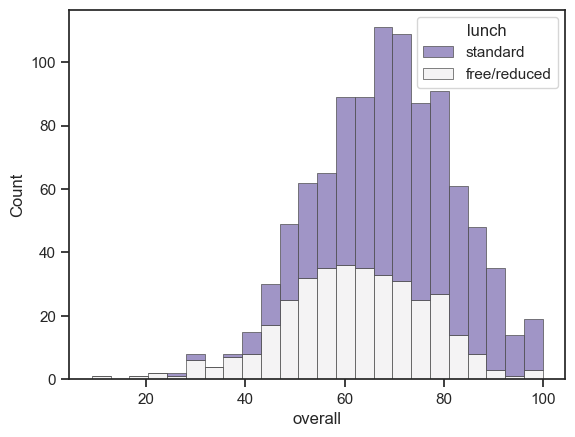

In [93]:
sns.set_theme(style="ticks")


sns.histplot(
    dataset,
    x="overall", hue="lunch",
    multiple="stack",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
    #log_scale=True,
)

<Axes: xlabel='overall', ylabel='Count'>

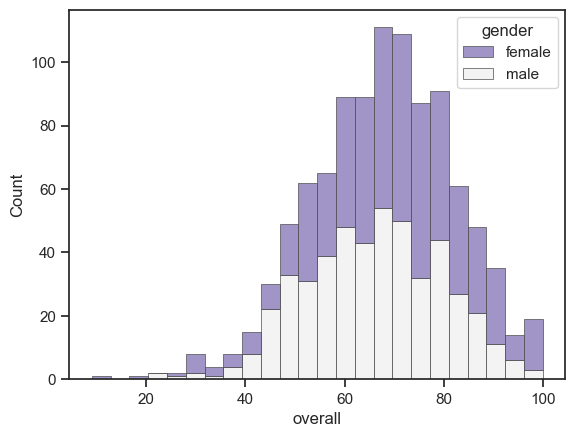

In [94]:
sns.set_theme(style="ticks")


sns.histplot(
    dataset,
    x="overall", hue="gender",
    multiple="stack",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
    #log_scale=True,
)

<Axes: xlabel='overall', ylabel='Count'>

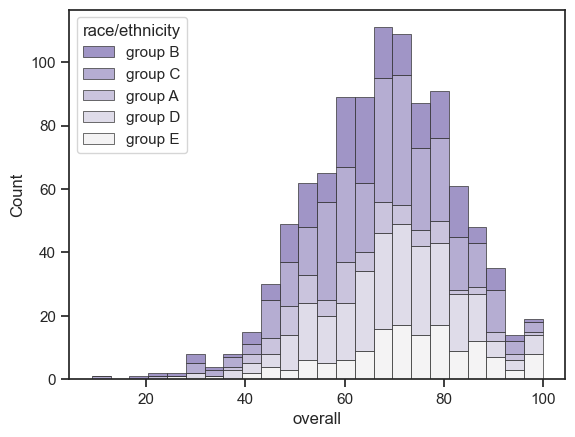

In [95]:
sns.set_theme(style="ticks")


sns.histplot(
    dataset,
    x="overall", hue="race/ethnicity",
    multiple="stack",
    palette="light:m_r",
    edgecolor=".2",
    linewidth=.5,
    #log_scale=True,
)

These histograms show the distribution of students according to the value specified in the 'hue' parameter. The x-axis shows the overall score.

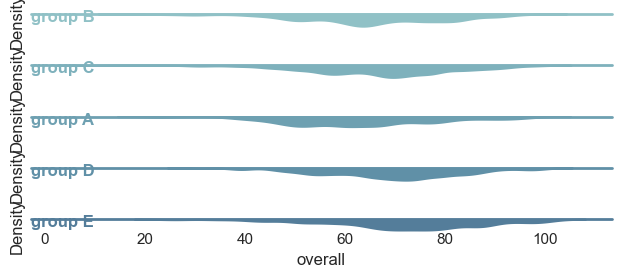

In [96]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the data

x = dataset['overall']
g = dataset['race/ethnicity']
df = dataset

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(dataset, row="race/ethnicity", hue="race/ethnicity", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, 
      'overall',
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, 
      linewidth=1.5)

#g.map(sns.kdeplot, "overall", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .22, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, 'overall')

# Set the subplots to overlap
g.fig.subplots_adjust(hspace=-5)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True)